# 1. Préparation des données pour la classification de textes

## 1.1 Importation des bibliothèques et optimisations

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
from sklearnex import patch_sklearn
patch_sklearn()  # Active les optimisations Intel.

Intel(R) Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## 1.2 Chargement des données textuelles

In [9]:
# chargement des données
df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/processed/df.csv", on_bad_lines='warn')
df.head()

,ImageID,Labels,Caption,Labels_list
0,1.jpg,19,A couple of men riding horses on top of a gree...,[19]
1,3.jpg,8 3 13,a black and silver clock tower at an intersect...,"[8, 3, 13]"
2,4.jpg,8 3 7,A train coming to a stop on the tracks out side.,"[8, 3, 7]"
3,6.jpg,5,A big airplane flying in the big blue sky,[5]
4,7.jpg,4,A man riding a motor bike across a forest.,[4]


## 1.3 Nettoyage du texte (stopwords, lemmatisation, caractères spéciaux)

In [13]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re

# Pour la lemmatisation (Ex. spaCy en anglais)
import spacy
nlp = spacy.load("en_core_web_sm")  


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
stop_words = set(stopwords.words('english'))  

def clean_text(text):
    # 1) Retirer caractères spéciaux (garde les lettres et chiffres)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))

    # 2) Tokeniser avec spaCy
    doc = nlp(text.lower())

    # 3) Lemmatiser et retirer les stopwords
    tokens = []
    for token in doc:
        if token.lemma_ not in stop_words and not token.is_space:
            tokens.append(token.lemma_)

    # 4) Join ou retourne la liste
    return " ".join(tokens)


In [15]:
df["cleaned_caption"] = df["Caption"].apply(clean_text)
print(df["cleaned_caption"].head())


0              couple man ride horse top green field
1    black silver clock tower intersection near tree
2                         train come stop track side
3                      big airplane fly big blue sky
4                  man ride motor bike across forest
Name: cleaned_caption, dtype: object


In [16]:
df.head()

,ImageID,Labels,Caption,Labels_list,cleaned_caption
0,1.jpg,19,A couple of men riding horses on top of a gree...,[19],couple man ride horse top green field
1,3.jpg,8 3 13,a black and silver clock tower at an intersect...,"[8, 3, 13]",black silver clock tower intersection near tree
2,4.jpg,8 3 7,A train coming to a stop on the tracks out side.,"[8, 3, 7]",train come stop track side
3,6.jpg,5,A big airplane flying in the big blue sky,[5],big airplane fly big blue sky
4,7.jpg,4,A man riding a motor bike across a forest.,[4],man ride motor bike across forest


## 1.4 Encodage des textes avec GloVe pré-entraîné

In [18]:
import gensim.downloader as api

# Ex : 'glove-wiki-gigaword-300' => 300 dimensions
w2v_model = api.load("glove-wiki-gigaword-300")

## 1.5 Vectorisation des textes 

In [19]:

def text_to_vector(text):
    words = text.split()  # splitted by espace
    vectors = []
    for w in words:
        if w in w2v_model:
            vectors.append(w2v_model[w])
    if len(vectors) == 0:
        return np.zeros(100)  # si aucun mot trouvé
    return np.mean(vectors, axis=0)  # moyenne

df["text_vector"] = df["cleaned_caption"].apply(text_to_vector)


In [20]:
df.head()

,ImageID,Labels,Caption,Labels_list,cleaned_caption,text_vector
0,1.jpg,19,A couple of men riding horses on top of a gree...,[19],couple man ride horse top green field,"[-0.017869432, 0.06275942, -0.08535, -0.129407..."
1,3.jpg,8 3 13,a black and silver clock tower at an intersect...,"[8, 3, 13]",black silver clock tower intersection near tree,"[-0.23992701, -0.025672572, -0.033024274, -0.2..."
2,4.jpg,8 3 7,A train coming to a stop on the tracks out side.,"[8, 3, 7]",train come stop track side,"[0.1362174, 0.13644302, -0.011995798, 0.017803..."
3,6.jpg,5,A big airplane flying in the big blue sky,[5],big airplane fly big blue sky,"[0.16080499, 0.08202099, 0.030285, -0.16835718..."
4,7.jpg,4,A man riding a motor bike across a forest.,[4],man ride motor bike across forest,"[-0.08408767, -0.21248998, -0.0332795, -0.1224..."


In [21]:
# Vérifier la forme des vecteurs
print(df["text_vector"].iloc[0].shape)

(300,)


In [22]:
# Transformer le texte en liste d'entiers
df["Labels_list"] = df["Labels"].apply(lambda x: list(map(int, x.split())))

In [23]:
df.head()

,ImageID,Labels,Caption,Labels_list,cleaned_caption,text_vector
0,1.jpg,19,A couple of men riding horses on top of a gree...,[19],couple man ride horse top green field,"[-0.017869432, 0.06275942, -0.08535, -0.129407..."
1,3.jpg,8 3 13,a black and silver clock tower at an intersect...,"[8, 3, 13]",black silver clock tower intersection near tree,"[-0.23992701, -0.025672572, -0.033024274, -0.2..."
2,4.jpg,8 3 7,A train coming to a stop on the tracks out side.,"[8, 3, 7]",train come stop track side,"[0.1362174, 0.13644302, -0.011995798, 0.017803..."
3,6.jpg,5,A big airplane flying in the big blue sky,[5],big airplane fly big blue sky,"[0.16080499, 0.08202099, 0.030285, -0.16835718..."
4,7.jpg,4,A man riding a motor bike across a forest.,[4],man ride motor bike across forest,"[-0.08408767, -0.21248998, -0.0332795, -0.1224..."


## 1.6 Division en ensembles d'entraînement, validation et test (70/15/15)

In [24]:
from sklearn.model_selection import train_test_split

# On va split en interne (70,15,15).

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print("Taille du set d'entraînement :", len(train_df))
print("Taille du set de validation :", len(val_df))
print("Taille du set de test :", len(test_df))

Taille du set d'entraînement : 11146
Taille du set de validation : 2388
Taille du set de test : 2389


In [25]:
# On convertit la colonne "text_vector" (série d'arrays) en un array 2D
X_train = np.vstack(train_df["text_vector"].values)
X_val   = np.vstack(val_df["text_vector"].values)
X_test  = np.vstack(test_df["text_vector"].values)

# Y : il faut binariser (multi-label)
# Exemple : usage d'un MultiLabelBinarizer
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(train_df["Labels_list"])
y_val   = mlb.transform(val_df["Labels_list"])
y_test  = mlb.transform(test_df["Labels_list"])


In [26]:
print(X_train)
print(y_train)

[[ 0.08836401  0.275418   -0.2952853  ... -0.06801834  0.21670668
   0.17506468]
 [-0.016728    0.0026046   0.03641052 ... -0.0211144   0.12047581
   0.33608398]
 [ 0.1381105  -0.04813713  0.05214499 ... -0.03441675  0.37461764
   0.1856325 ]
 ...
 [ 0.04022159  0.09525599 -0.005645   ...  0.635613    0.1587872
  -0.2400361 ]
 [-0.106258   -0.44195205 -0.06508367 ... -0.1638196  -0.06103678
   0.0397332 ]
 [ 0.16146882  0.13184041 -0.22514482 ... -0.233807    0.1012366
  -0.05196859]]
[[0 0 0 ... 1 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [27]:
#Normalisations de x_train
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 2. Modèles baseline avec algorithmes de Machine Learning classiques

## 2.1 Classification multi-label avec Régression Logistique

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

lr = MultiOutputClassifier(LogisticRegression(max_iter=200))
lr.fit(X_train, y_train)  # multi-label => scikit-learn gère un vs rest

# évaluation
from sklearn.metrics import f1_score

y_val_pred = lr.predict(X_val)
f1_macro = f1_score(y_val, y_val_pred, average='macro')
print("Baseline LR - F1 macro:", f1_macro)


Baseline LR - F1 macro: 0.7100897147837606


## 2.2 Classification multi-label avec Random Forest

In [23]:
import warnings
warnings.filterwarnings("ignore")  # Masque TOUS les warnings (risqué)

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf =  MultiOutputClassifier(RandomForestClassifier())
rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)
f1_macro_rf = f1_score(y_val, y_val_pred_rf, average='macro')
print("Baseline RF - F1 macro:", f1_macro_rf)


Baseline RF - F1 macro: 0.5540070220995524


## 2.3 Classification multi-label avec SVM

In [26]:
from sklearn.svm import SVC

svm = MultiOutputClassifier(SVC())
svm.fit(X_train_scaled, y_train)

y_val_pred_svm = svm.predict(X_val_scaled)
f1_macro_svm = f1_score(y_val, y_val_pred_svm, average='macro')
print("Baseline SVM - F1 macro:", f1_macro_svm)

Baseline SVM - F1 macro: 0.7344954617046718


# 3. Expérimentations avec architectures de Deep Learning pour le texte

## 3.1 Préparation commune aux expérimentations Deep Learning

In [28]:
df.head()

,ImageID,Labels,Caption,Labels_list,cleaned_caption,text_vector
0,1.jpg,19,A couple of men riding horses on top of a gree...,[19],couple man ride horse top green field,"[-0.017869432, 0.06275942, -0.08535, -0.129407..."
1,3.jpg,8 3 13,a black and silver clock tower at an intersect...,"[8, 3, 13]",black silver clock tower intersection near tree,"[-0.23992701, -0.025672572, -0.033024274, -0.2..."
2,4.jpg,8 3 7,A train coming to a stop on the tracks out side.,"[8, 3, 7]",train come stop track side,"[0.1362174, 0.13644302, -0.011995798, 0.017803..."
3,6.jpg,5,A big airplane flying in the big blue sky,[5],big airplane fly big blue sky,"[0.16080499, 0.08202099, 0.030285, -0.16835718..."
4,7.jpg,4,A man riding a motor bike across a forest.,[4],man ride motor bike across forest,"[-0.08408767, -0.21248998, -0.0332795, -0.1224..."


In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

'''
    2. Tokenisation et vectorisation avec Keras Tokenizer
    Nous allons transformer le texte en séquences d’entiers et les “paddér” pour obtenir des séquences de même longueur.
'''

# Liste de textes
texts = df["cleaned_caption"].tolist()

# Définir le nombre maximal de mots dans le vocabulaire
max_words = 10000  
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

# Convertir les textes en séquences d'entiers
sequences = tokenizer.texts_to_sequences(texts)

# Choisir une longueur max (par exemple 100 tokens)
max_len = 100  
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

# Obtenir le word_index (dictionnaire mot -> indice)
word_index = tokenizer.word_index
print(f"Taille du vocabulaire: {len(word_index)}")

Taille du vocabulaire: 3993


In [3]:
import tensorflow as tf
print("Périphériques disponibles:", tf.config.list_physical_devices())

Périphériques disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
print(tf.__version__)  # Should output 2.12.0
print(tf.config.list_physical_devices())

2.12.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [5]:
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU'), 'GPU')

In [30]:
'''
    3. Préparer les labels en multi-label
    Nous utilisons MultiLabelBinarizer pour transformer les listes de labels en vecteurs binaires.
'''

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(df["Labels_list"])

print("Nombre de classes :", len(mlb.classes_))


Nombre de classes : 17


In [32]:
'''
    4. Split train/val/test
    On conserve la même répartition que pour les images (70% train, 15% val, 15% test).
    L’ordre doit être identique pour la fusion future, mais ici on travaille uniquement sur le texte.
'''

# Calculer les tailles
train_size = int(0.70 * len(df))
val_size = int(0.15 * len(df))
test_size = len(df) - train_size - val_size

# Utiliser iloc pour garder l'ordre
X_train = padded_sequences[:train_size]
X_val = padded_sequences[train_size:train_size+val_size]
X_test = padded_sequences[train_size+val_size:]

y_train = labels[:train_size]
y_val = labels[train_size:train_size+val_size]
y_test = labels[train_size+val_size:]


## 3.2 Expérimentation 1 : LSTM from scratch (avec embedding aléatoire)

In [33]:
'''
    Modèle LSTM simple
    Ce modèle va apprendre son embedding pendant l’entraînement.
'''

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Définir les hyperparamètres
embedding_dim = 100  # taille de l'embedding
lstm_units = 128     # nombre de neurones dans la couche LSTM
num_classes = len(mlb.classes_)  # nombre de labels (ex : 19)

# Construire le modèle
model_exp1 = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(lstm_units),
    Dropout(0.5),
    Dense(num_classes, activation='sigmoid')  # Sigmoid pour multi-label
])

# Option 2: Construire le modèle explicitement avec une forme d'entrée
model_exp1.build(input_shape=(None, max_len))

model_exp1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_exp1.summary()

# Entraîner le modèle
history1 = model_exp1.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          1000000   
                                                                 
 lstm (LSTM)                 (None, 128)               117248    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 17)                2193      
                                                                 
Total params: 1,119,441
Trainable params: 1,119,441
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
349/349 [==============================] - 58s 154ms/step - loss: 0.3058 - accuracy: 0.1920 - val_loss: 0.2802 - val_accuracy: 0.2387
Epoch 2/10
349/349 [=============

## 3.3 Expérimentation 2 : LSTM avec embedding pré-entraîné (GloVe)

In [37]:
import os
import requests
import zipfile

# Télécharger GloVe si nécessaire
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_path = "glove.6B.zip"
glove_extract_dir = "glove"

if not os.path.exists(glove_extract_dir):
    os.makedirs(glove_extract_dir)
    
    # Télécharger le fichier
    if not os.path.exists(glove_path):
        print("Téléchargement de GloVe...")
        response = requests.get(glove_url)
        with open(glove_path, 'wb') as f:
            f.write(response.content)
        print("Téléchargement terminé.")
    
    # Extraire le fichier
    with zipfile.ZipFile(glove_path, 'r') as zip_ref:
        zip_ref.extractall(glove_extract_dir)
    print("Extraction terminée.")

# Chemin vers les embeddings de dimension 100
glove_file = os.path.join(glove_extract_dir, "glove.6B.100d.txt")

Téléchargement de GloVe...
Téléchargement terminé.
Extraction terminée.


In [38]:

def load_glove_embeddings(glove_file, word_index, embedding_dim=100):
    print(f"Chargement des embeddings GloVe depuis {glove_file}...")
    
    # Dictionnaire pour stocker les embeddings
    embeddings_index = {}
    
    # Ouvrir le fichier GloVe
    with open(glove_file, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            # Convertir les valeurs en array numpy
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    
    print(f"Trouvé {len(embeddings_index)} vecteurs GloVe.")
    
    # Préparer la matrice d'embedding
    # +1 pour l'indice 0 qui est réservé au padding
    vocab_size = min(len(word_index) + 1, max_words + 1)
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Compteurs pour les statistiques
    hits = 0
    misses = 0
    
    # Remplir la matrice avec les embeddings GloVe
    for word, i in word_index.items():
        # Ne pas dépasser max_words
        if i >= max_words:
            continue
            
        # Récupérer le vecteur d'embedding pour ce mot
        embedding_vector = embeddings_index.get(word)
        
        if embedding_vector is not None:
            # Mots trouvés dans GloVe
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            # Mots non trouvés dans GloVe (restent à zéro ou peuvent être initialisés aléatoirement)
            misses += 1
    
    print(f"Mots trouvés dans GloVe: {hits}")
    print(f"Mots absents de GloVe: {misses}")
    print(f"Couverture: {hits/(hits+misses)*100:.2f}%")
    
    return embedding_matrix, vocab_size

# Créer la matrice d'embedding
embedding_dim = 100
embedding_matrix, vocab_size = load_glove_embeddings(glove_file, word_index, embedding_dim)


Chargement des embeddings GloVe depuis glove\glove.6B.100d.txt...
Trouvé 400000 vecteurs GloVe.
Mots trouvés dans GloVe: 3787
Mots absents de GloVe: 206
Couverture: 94.84%


## Construction du modèle LSTM avec GloVe

In [39]:
from tensorflow.keras.initializers import Constant

def build_lstm_with_glove(embedding_matrix, max_len, lstm_units, num_classes, vocab_size, embedding_dim, trainable_embeddings=False):
    model_exp2 = Sequential([
        # Couche d'embedding initialisée avec GloVe
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            embeddings_initializer=Constant(embedding_matrix),  # Utiliser les embeddings GloVe
            input_length=max_len,
            trainable=trainable_embeddings  # False = embeddings fixes, True = fine-tuning
        ),
        # Couche LSTM
        LSTM(lstm_units),
        # Dropout pour éviter le surapprentissage
        Dropout(0.5),
        # Couche de sortie
        Dense(num_classes, activation='sigmoid')  # Sigmoid pour multi-label
    ])
    
    # Compiler le modèle
    model_exp2.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model_exp2

# Construire le modèle
lstm_units = 128
model_lstm_glove = build_lstm_with_glove(
    embedding_matrix=embedding_matrix,
    max_len=max_len,
    lstm_units=lstm_units,
    num_classes=num_classes,
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    trainable_embeddings=True  # Mettre à False pour garder les embeddings fixes
)

# Construire le modèle avec la forme d'entrée
model_lstm_glove.build(input_shape=(None, max_len))  

# Afficher le résumé du modèle
model_lstm_glove.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 100)          399400    
                                                                 
 lstm_1 (LSTM)               (None, 128)               117248    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 17)                2193      
                                                                 
Total params: 518,841
Trainable params: 518,841
Non-trainable params: 0
_________________________________________________________________


In [40]:
# Entraîner le modèle
history = model_lstm_glove.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
349/349 [==============================] - 49s 129ms/step - loss: 0.3075 - accuracy: 0.1927 - val_loss: 0.2804 - val_accuracy: 0.2387
Epoch 2/10
349/349 [==============================] - 47s 134ms/step - loss: 0.2885 - accuracy: 0.2381 - val_loss: 0.2799 - val_accuracy: 0.2387
Epoch 3/10
349/349 [==============================] - 47s 136ms/step - loss: 0.2862 - accuracy: 0.2465 - val_loss: 0.2801 - val_accuracy: 0.2387
Epoch 4/10
349/349 [==============================] - 45s 128ms/step - loss: 0.2857 - accuracy: 0.2472 - val_loss: 0.2798 - val_accuracy: 0.2387
Epoch 5/10
349/349 [==============================] - 44s 127ms/step - loss: 0.2851 - accuracy: 0.2475 - val_loss: 0.2797 - val_accuracy: 0.2387
Epoch 6/10
349/349 [==============================] - 51s 147ms/step - loss: 0.2846 - accuracy: 0.2475 - val_loss: 0.2797 - val_accuracy: 0.2387
Epoch 7/10
349/349 [==============================] - 53s 151ms/step - loss: 0.2841 - accuracy: 0.2475 - val_loss: 0.2799 - val_ac

In [41]:
from sklearn.metrics import f1_score, classification_report

# Évaluation sur l'ensemble de test
print("\nÉvaluation du modèle avec GloVe:")
test_loss, test_accuracy = model_lstm_glove.evaluate(X_test, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Prédictions (seuil à 0.5 pour la classification binaire)
y_pred = (model_lstm_glove.predict(X_test) > 0.5).astype(int)

# Calcul du F1-score (macro-moyenne sur toutes les classes)
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"Test F1 macro: {f1_macro:.4f}")

target_names = [str(cls) for cls in mlb.classes_]

# Rapport de classification détaillé
print("\nRapport de classification par classe:")
print(classification_report(y_test, y_pred, target_names=target_names))


Évaluation du modèle avec GloVe:
75/75 [==============================] - 4s 55ms/step - loss: 0.2833 - accuracy: 0.2432
Test loss: 0.2833
Test accuracy: 0.2432
75/75 [==============================] - 4s 45ms/step
Test F1 macro: 0.0000

Rapport de classification par classe:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00       192
           3       0.00      0.00      0.00       656
           4       0.00      0.00      0.00       195
           5       0.00      0.00      0.00       158
           6       0.00      0.00      0.00       215
           7       0.00      0.00      0.00       171
           8       0.00      0.00      0.00       306
           9       0.00      0.00      0.00       165
          10       0.00      0.00      0.00       239
          11       0.00      0.00      0.00        82
          13       0.00      0.00      0.00        97
          14       0.00      0.00      0.00        44
          15       0

c:\Users\Dell\OneDrive\Desktop\Projet_final_BIHAR\Jean_Duckens_Final_Evaluation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\OneDrive\Desktop\Projet_final_BIHAR\Jean_Duckens_Final_Evaluation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\OneDrive\Desktop\Projet_final_BIHAR\Jean_Duckens_Final_Evaluation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted label

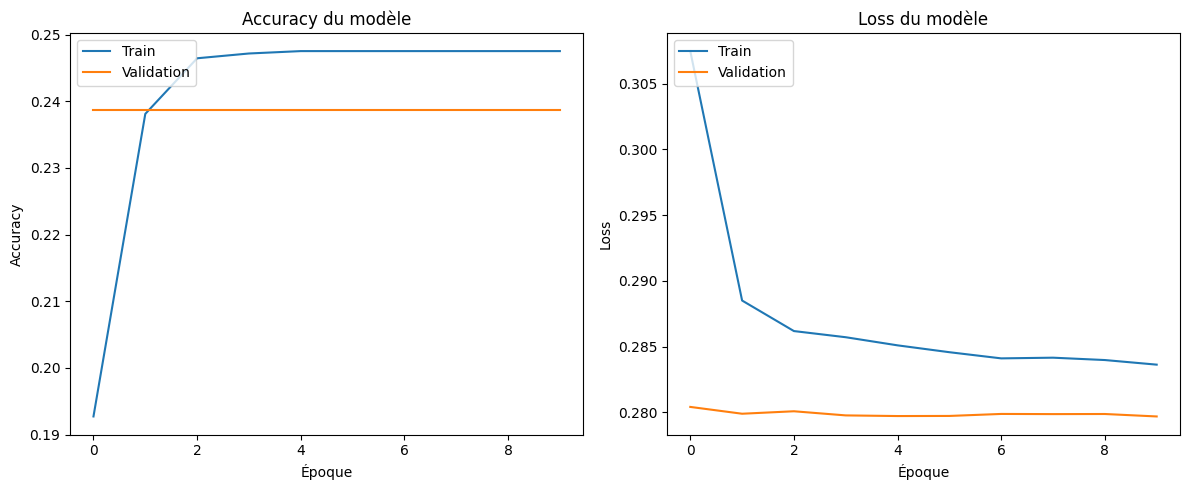

In [42]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Tracer l'évolution de l'accuracy et de la loss
    plt.figure(figsize=(12, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Accuracy du modèle')
    plt.ylabel('Accuracy')
    plt.xlabel('Époque')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Loss du modèle')
    plt.ylabel('Loss')
    plt.xlabel('Époque')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Visualiser l'historique d'entraînement
plot_training_history(history)

In [44]:
y_probs = model_lstm_glove.predict(X_test)
print(y_probs[:5])


75/75 [==============================] - 3s 44ms/step
[[0.06814577 0.27779087 0.08400325 0.06680722 0.08278292 0.07272079
  0.13653915 0.06695946 0.09115402 0.04315368 0.03404336 0.01590379
  0.11803959 0.07027589 0.09557001 0.09853639 0.06914102]
 [0.06814577 0.27779084 0.08400325 0.0668072  0.08278293 0.07272081
  0.13653915 0.06695946 0.09115402 0.04315368 0.03404337 0.01590379
  0.11803959 0.07027589 0.09557001 0.09853639 0.06914102]
 [0.06814577 0.27779087 0.08400325 0.06680722 0.08278293 0.07272081
  0.13653915 0.06695948 0.09115402 0.04315368 0.03404337 0.01590379
  0.11803959 0.07027589 0.09557001 0.09853639 0.06914102]
 [0.06814575 0.27779084 0.08400325 0.06680722 0.08278293 0.07272079
  0.13653915 0.06695948 0.09115402 0.04315368 0.03404336 0.01590379
  0.11803959 0.07027589 0.09557001 0.09853639 0.06914102]
 [0.06814577 0.27779084 0.08400323 0.06680722 0.08278293 0.07272079
  0.13653915 0.06695946 0.09115402 0.04315368 0.03404337 0.01590379
  0.11803959 0.07027589 0.09557001

## 3.4 Expérimentation 3 : Architecture hybride LSTM + CNN 1D

In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Concatenate, Input
from tensorflow.keras.models import Model

input_layer = Input(shape=(max_len,))  # Séquence d'entiers

# Embedding (on peut utiliser l'embedding pré-entraîné comme dans Exp 2)
embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len,
                            weights=[embedding_matrix], trainable=False)(input_layer)

# Branche LSTM
lstm_out = LSTM(lstm_units)(embedding_layer)

# Branche CNN 1D
conv_out = Conv1D(filters=64, kernel_size=3, activation='relu')(embedding_layer)
pool_out = GlobalMaxPooling1D()(conv_out)

# Concaténer les deux branches
concat = Concatenate()([lstm_out, pool_out])
drop = Dropout(0.5)(concat)
output_layer = Dense(num_classes, activation='sigmoid')(drop)

model_exp3_ = Model(inputs=input_layer, outputs=output_layer)
model_exp3_.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_exp3_.build(input_shape=(None, max_len)) 

model_exp3_.summary()

history3_ = model_exp3_.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 100)]        0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 100, 300)     3000000     ['input_3[0][0]']                
                                                                                                  
 conv1d_2 (Conv1D)              (None, 98, 64)       57664       ['embedding_4[0][0]']            
                                                                                                  
 lstm_4 (LSTM)                  (None, 128)          219648      ['embedding_4[0][0]']            
                                                                                            

In [64]:
# Évaluation sur l'ensemble de test
print("\nÉvaluation du modèle hybride:")
test_loss, test_accuracy = model_exp3_.evaluate(X_test, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Prédictions (seuil à 0.5 pour la classification binaire)
y_pred = (model_exp3_.predict(X_test) > 0.5).astype(int)

# Calcul du F1-score (macro-moyenne sur toutes les classes)
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"Test F1 macro: {f1_macro:.4f}")

target_names = [str(cls) for cls in mlb.classes_]

# Rapport de classification détaillé
print("\nRapport de classification par classe:")
print(classification_report(y_test, y_pred, target_names=target_names))


Évaluation du modèle hybride:
75/75 [==============================] - 6s 80ms/step - loss: 0.1339 - accuracy: 0.6467
Test loss: 0.1339
Test accuracy: 0.6467
75/75 [==============================] - 7s 88ms/step
Test F1 macro: 0.7050

Rapport de classification par classe:
              precision    recall  f1-score   support

           2       0.86      0.26      0.39       192
           3       0.67      0.38      0.49       656
           4       1.00      0.67      0.80       195
           5       0.99      0.92      0.95       158
           6       0.99      0.67      0.80       215
           7       0.95      0.90      0.92       171
           8       0.92      0.32      0.47       306
           9       0.96      0.67      0.79       165
          10       0.90      0.28      0.42       239
          11       1.00      0.55      0.71        82
          13       1.00      0.42      0.59        97
          14       1.00      0.43      0.60        44
          15       0.90

c:\Users\Dell\OneDrive\Desktop\Projet_final_BIHAR\Jean_Duckens_Final_Evaluation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


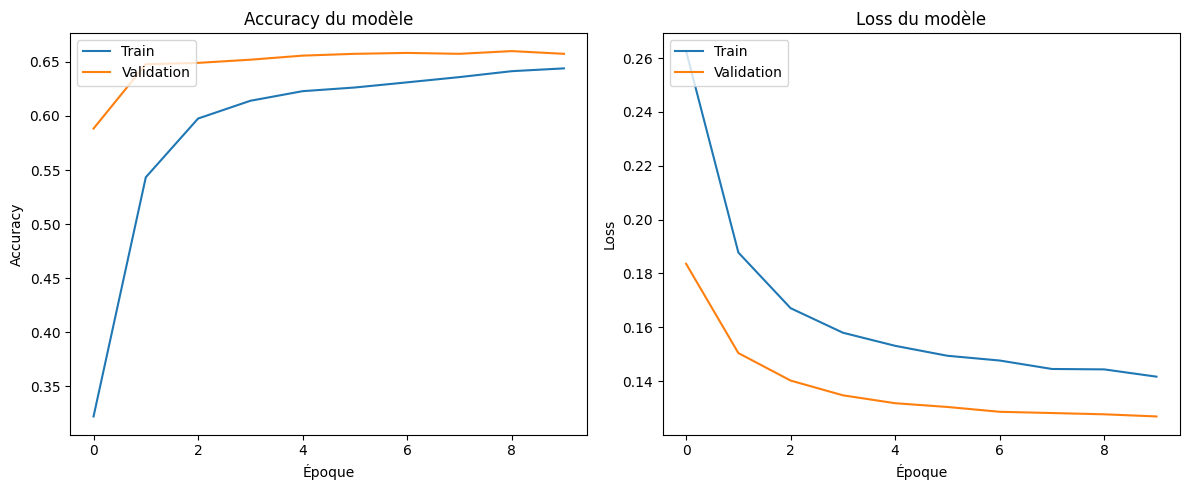

In [49]:
def plot_training_history(history):
    # Tracer l'évolution de l'accuracy et de la loss
    plt.figure(figsize=(12, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Accuracy du modèle')
    plt.ylabel('Accuracy')
    plt.xlabel('Époque')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Loss du modèle')
    plt.ylabel('Loss')
    plt.xlabel('Époque')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Visualiser l'historique d'entraînement
plot_training_history(history3)

## 3.5 Amélioration du modèle hybride avec BiLSTM et optimisations

In [66]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM, Conv1D, GlobalMaxPooling1D, BatchNormalization, Concatenate, Dense, Dropout)
from tensorflow.keras.models import Model

# --- Paramètres du modèle ---
max_len = 100                   # Longueur maximale des séquences
max_words = 10000               # Taille du vocabulaire à utiliser
embedding_dim = 300             # Dimensions des embeddings (GloVe 300D)
lstm_units = 128                # Nombre d'unités dans la couche LSTM
num_classes = 17                # Nombre de labels à prédire

# --- Chargement des embeddings GloVe ---
def load_glove_embeddings(glove_file, word_index, embedding_dim=300):
    print(f"Chargement des embeddings GloVe depuis {glove_file}...")
    
    # Dictionnaire pour stocker les embeddings
    embeddings_index = {}
    
    # Ouvrir le fichier GloVe
    with open(glove_file, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            # Convertir les valeurs en array numpy
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    
    print(f"Trouvé {len(embeddings_index)} vecteurs GloVe.")
    
    # Préparer la matrice d'embedding
    # Utiliser exactement max_words pour que la dimension corresponde à celle de la couche Embedding
    embedding_matrix = np.zeros((max_words, embedding_dim))
    
    # Compteurs pour les statistiques
    hits = 0
    misses = 0
    
    # Remplir la matrice avec les embeddings GloVe
    for word, i in word_index.items():
        # Ne pas dépasser max_words
        if i >= max_words:
            continue
            
        # Récupérer le vecteur d'embedding pour ce mot
        embedding_vector = embeddings_index.get(word)
        
        if embedding_vector is not None:
            # Mots trouvés dans GloVe
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            # Mots non trouvés dans GloVe (restent à zéro ou peuvent être initialisés aléatoirement)
            misses += 1
    
    print(f"Mots trouvés dans GloVe: {hits}")
    print(f"Mots absents de GloVe: {misses}")
    print(f"Couverture: {hits/(hits+misses)*100:.2f}%")
    
    return embedding_matrix

# Chemin vers les embeddings GloVe de dimension 300
glove_file = os.path.join(glove_extract_dir, "glove.6B.300d.txt")

# Créer la matrice d'embedding
embedding_matrix = load_glove_embeddings(glove_file, word_index, embedding_dim)



Chargement des embeddings GloVe depuis glove\glove.6B.300d.txt...
Trouvé 400000 vecteurs GloVe.
Mots trouvés dans GloVe: 3787
Mots absents de GloVe: 206
Couverture: 94.84%


In [67]:
# --- Construction du modèle hybride LSTM-CNN ---

# 1. Input Layer
input_layer = Input(shape=(max_len,), name="Input_Text_Sequence")

# 2. Embedding Layer avec les poids GloVe
embedding_layer = Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    input_length=max_len,
    weights=[embedding_matrix],
    trainable=True,
    name="Pretrained_Embedding"
)(input_layer)

# 3. Branche LSTM : Utilise un Bidirectional LSTM pour capturer le contexte dans les deux directions
lstm_branch = Bidirectional(LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2, name="LSTM"))(embedding_layer)
lstm_branch = Dropout(0.3, name="LSTM_Dropout")(lstm_branch)

# 4. Branche CNN 1D : Extraction de motifs locaux dans les séquences
conv_branch = Conv1D(filters=128, kernel_size=3, activation='relu', name="Conv1D_1")(embedding_layer)
conv_branch = BatchNormalization(name="BN_Conv1D_1")(conv_branch)
conv_branch = Dropout(0.3, name="Dropout_Conv1D_1")(conv_branch)
conv_branch = Conv1D(filters=128, kernel_size=3, activation='relu', name="Conv1D_2")(conv_branch)
conv_branch = BatchNormalization(name="BN_Conv1D_2")(conv_branch)
conv_branch = GlobalMaxPooling1D(name="GlobalMaxPool")(conv_branch)

# 5. Concatenation des branches LSTM et CNN
concatenated = Concatenate(name="Concatenate")([lstm_branch, conv_branch])

# 6. Couche Dense intermédiaire
dense_layer = Dense(128, activation='relu', name="Dense_1")(concatenated)
dense_layer = Dropout(0.3, name="Dropout_Dense_1")(dense_layer)

# 7. Couche de sortie avec activation sigmoid pour classification multi-label
output_layer = Dense(num_classes, activation='sigmoid', name="Output")(dense_layer)

# 8. Création et compilation du modèle
model_exp3_am = Model(inputs=input_layer, outputs=output_layer, name="Hybrid_LSTM_CNN_Model")
model_exp3_am.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Construire le modèle avec la forme d'entrée
model_exp3_am.build(input_shape=(None, max_len)) 

# Afficher le résumé du modèle
model_exp3_am.summary()

# --- Entraînement du modèle ---
history3_am = model_exp3_am.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Model: "Hybrid_LSTM_CNN_Model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Input_Text_Sequence (InputLaye  [(None, 100)]       0           []                               
 r)                                                                                               
                                                                                                  
 Pretrained_Embedding (Embeddin  (None, 100, 300)    3000000     ['Input_Text_Sequence[0][0]']    
 g)                                                                                               
                                                                                                  
 Conv1D_1 (Conv1D)              (None, 98, 128)      115328      ['Pretrained_Embedding[0][0]']   
                                                                              

In [ ]:
from sklearn.metrics import f1_score, classification_report

# Évaluation sur l'ensemble de test
print("\nÉvaluation du modèle hybride:")
test_loss, test_accuracy = model_exp3_am.evaluate(X_test, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Prédictions (seuil à 0.5 pour la classification binaire)
y_pred = (model_exp3_am.predict(X_test) > 0.5).astype(int)

# Calcul du F1-score (macro-moyenne sur toutes les classes)
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"Test F1 macro: {f1_macro:.4f}")

target_names = [str(cls) for cls in mlb.classes_]

# Rapport de classification détaillé
print("\nRapport de classification par classe:")
print(classification_report(y_test, y_pred, target_names=target_names))


Évaluation du modèle avec GloVe:
75/75 [==============================] - 13s 178ms/step - loss: 0.1733 - accuracy: 0.6517
Test loss: 0.1733
Test accuracy: 0.6517
75/75 [==============================] - 16s 193ms/step
Test F1 macro: 0.7253

Rapport de classification par classe:
              precision    recall  f1-score   support

           2       0.88      0.34      0.49       192
           3       0.60      0.54      0.57       656
           4       0.94      0.69      0.80       195
           5       0.98      0.94      0.96       158
           6       0.90      0.69      0.78       215
           7       0.95      0.91      0.93       171
           8       0.76      0.36      0.49       306
           9       0.87      0.71      0.78       165
          10       0.71      0.38      0.49       239
          11       0.94      0.54      0.68        82
          13       0.84      0.54      0.65        97
          14       1.00      0.48      0.65        44
          15    

c:\Users\Dell\OneDrive\Desktop\Projet_final_BIHAR\Jean_Duckens_Final_Evaluation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
# Enregistrer le modèle
model_exp3_am.save("C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/model/model_hybride_exp3_am.h5")


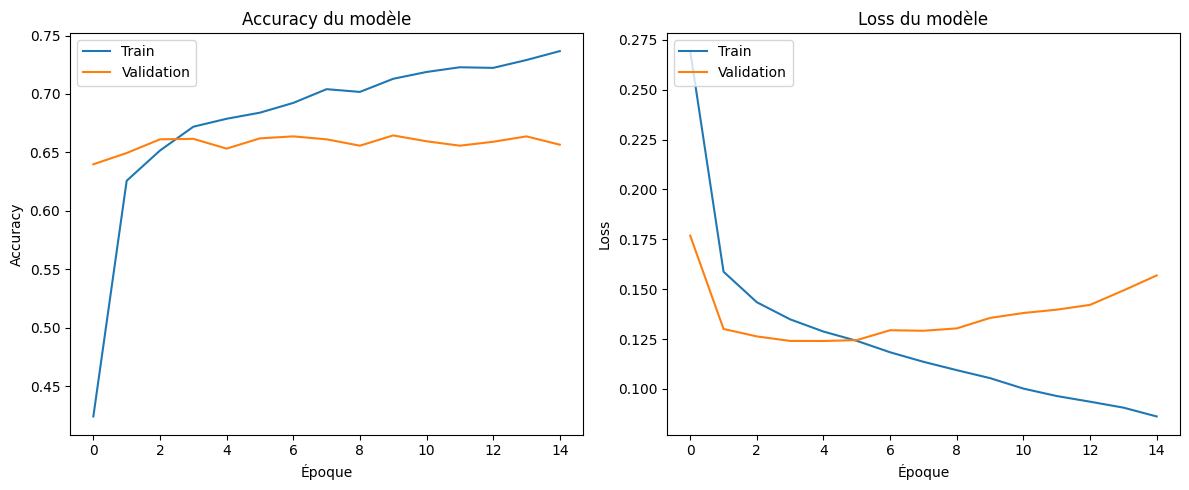

In [70]:
def plot_training_history(history):
    # Tracer l'évolution de l'accuracy et de la loss
    plt.figure(figsize=(12, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Accuracy du modèle')
    plt.ylabel('Accuracy')
    plt.xlabel('Époque')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Loss du modèle')
    plt.ylabel('Loss')
    plt.xlabel('Époque')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Visualiser l'historique d'entraînement
plot_training_history(history3_am)

In [ ]:
# 4. Comparaison des performances et sélection du modèle optimal

## 4.1 Tableau comparatif des performances pour tous les modèles
# Créer un DataFrame de comparaison des performances
models_comparison = {
    'LogisticRegression': {'F1-macro': f1_macro, 'Accuracy': test_accuracy_lr},
    'RandomForest': {'F1-macro': f1_macro_rf, 'Accuracy': test_accuracy_rf}, 
    'SVM': {'F1-macro': f1_macro_svm, 'Accuracy': test_accuracy_svm},
    'LSTM_scratch': {'F1-macro': f1_macro_lstm1, 'Accuracy': test_accuracy_lstm1},
    'LSTM_GloVe': {'F1-macro': f1_macro, 'Accuracy': test_accuracy},
    'LSTM_CNN_hybrid': {'F1-macro': f1_macro_hybrid, 'Accuracy': test_accuracy_hybrid},
    'BiLSTM_CNN_optimized': {'F1-macro': f1_macro, 'Accuracy': test_accuracy}
}

comparison_df = pd.DataFrame(models_comparison).T
comparison_df = comparison_df.sort_values('F1-macro', ascending=False)
comparison_df

In [ ]:
# 5. Interprétabilité et propositions d'amélioration

## 5.1 Application de LIME pour interpréter les décisions du modèle
import lime
from lime.lime_text import LimeTextExplainer

# Fonction pour prédire avec le modèle (à adapter selon votre modèle)
def predict_proba_fn(texts):
    # Prétraiter les textes comme pour l'entraînement
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post')
    return model_final.predict(padded)  # Utiliser votre meilleur modèle

# Créer l'explainer LIME
explainer = LimeTextExplainer(class_names=[str(i) for i in mlb.classes_])

# Choisir un texte d'exemple
idx = 5  # Choisir un index intéressant
text_to_explain = df['cleaned_caption'].iloc[idx]
true_label = y_test[idx]
pred_label = y_pred[idx]

# Générer l'explication
exp = explainer.explain_instance(
    text_to_explain, 
    predict_proba_fn,
    num_features=10,
    top_labels=3
)

# Visualiser l'explication
exp.show_in_notebook(text=True)

In [ ]:
## 5.2 Analyse des erreurs de classification

# Fonction pour trouver les exemples mal classifiés
def find_misclassified(y_true, y_pred, texts, n_examples=5):
    # Calculer la différence entre vrai et prédit
    errors = np.sum(np.abs(y_true - y_pred), axis=1)
    # Trouver les indices des exemples mal classifiés
    misclassified_indices = np.argsort(errors)[::-1][:n_examples]
    
    return misclassified_indices

# Obtenir des exemples mal classifiés
misclassified_indices = find_misclassified(y_test, y_pred, test_df['cleaned_caption'].values)

# Afficher les exemples
for idx in misclassified_indices:
    print(f"Texte: {test_df['cleaned_caption'].iloc[idx]}")
    print(f"Vraies étiquettes: {mlb.classes_[y_test[idx] == 1]}")
    print(f"Étiquettes prédites: {mlb.classes_[y_pred[idx] == 1]}")
    print("---")

## 5.3 Propositions d'amélioration et travaux futurs
"""
Propositions d'amélioration:
1. Augmentation de données textuelles pour les classes minoritaires
2. Utilisation de modèles pré-entraînés comme BERT ou RoBERTa
3. Implémentation d'une attention hiérarchique pour mieux capturer les relations contextuelles
4. Ajustement des seuils de classification spécifiques à chaque classe
5. Techniques d'ensemble combinant plusieurs modèles
"""